In [1]:
import geopandas as gpd
import sys
sys.path.append('..')
import osmnx as ox

# Graph creation


The drive graph is generated using the polygon GeoDataFrame and the local CRS.  

Ensure that the local CRS is a Projected CRS (e.g., UTM) rather than a Geographic CRS (e.g., EPSG:4326 - WGS84) to maintain accurate distance calculations.  


In [2]:
geocode= 81993 # Tula oblast geocode from OSM
polygon = ox.geocode_to_gdf(f'R{geocode}', by_osmid=True)
local_crs = 32637

In [3]:
from transport_frames.graph import get_graph_from_polygon

graph = get_graph_from_polygon(polygon,local_crs)

2025-03-01 07:15:51.923 | INFO     | iduedu.modules.drive_walk_builder:get_drive_graph_by_poly:91 - Downloading drive graph from OSM, it may take a while for large territory ...


# Frame

Frame consists of federal and regional roads from the graph, adding exit attributes and district centers attributes to the nodes.

In [4]:
regions = gpd.read_file('regions.geojson')
admin_centers = gpd.read_file('region_points.geojson')

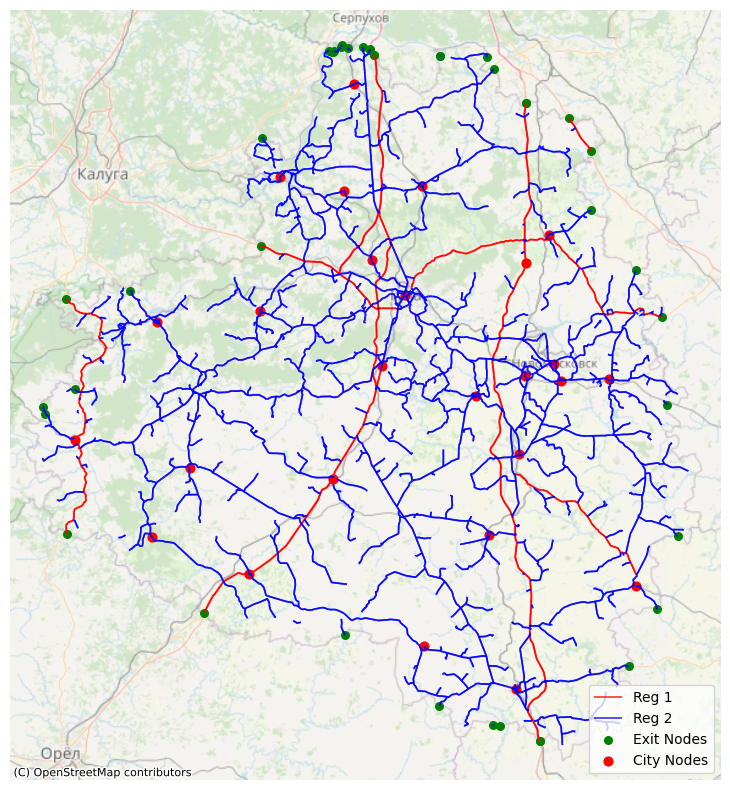

In [5]:
from transport_frames.frame import get_frame, plot_frame

f = get_frame(graph,admin_centers,polygon,regions)

plot_frame(f)

# Weighted frame

Weights are assigned to the edges and nodes based on the expected popularity of the path between pairs of exits.

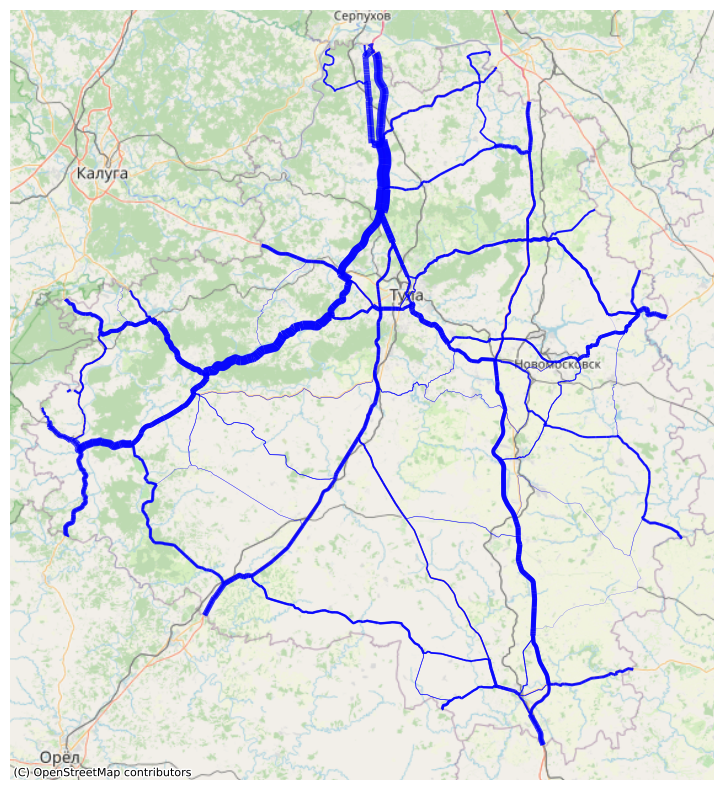

In [6]:
from transport_frames.frame import weigh_roads, plot_weighted_roads

weighted_frame = weigh_roads(f)

plot_weighted_roads(weighted_frame)

# Intermodal graph

Intermodal graph is used for connectivity indicators and routes extraction. It can be obtained using ``iduedu`` library.

In [ ]:
from iduedu import get_intermodal_graph

inter_graph = get_intermodal_graph(osm_id=geocode)